## Week 2 - Day 2 - Probability & Distributions

BinX Tech AI & ML Internship

Topics:
- Probability basics: favorable over total outcomes
- Core rules: complement, addition, multiplication
- Conditional probability P(A|B)
- Bayes' theorem: prior, likelihood, posterior
- Common distributions: normal, binomial, uniform

The parts under here are for testing and showcasing the lesson content, and the Day 2 task will be at the end.

## Core Rules

Complement, addition, and multiplication (independent events), demonstrated with a fair six-sided die.

In [1]:
# P(rolling a 4) and its complement
p_four = 1 / 6
p_not_four = 1 - p_four
print("P(4):", round(p_four, 3), " P(not 4):", round(p_not_four, 3))

# P(rolling a 4 or a 6) - mutually exclusive, so P(A and B) = 0
p_four_or_six = p_four + (1 / 6) - 0
print("P(4 or 6):", round(p_four_or_six, 3))

# P(rolling a 4 on die 1 AND a 6 on die 2) - independent events
p_both = p_four * (1 / 6)
print("P(4 then 6):", round(p_both, 3))

P(4): 0.167  P(not 4): 0.833
P(4 or 6): 0.333
P(4 then 6): 0.028


## Conditional Probability & Bayes' Theorem

A small worked example: a factory has two machines. Machine A makes 60% of the products and has a 2% defect rate;
Machine B makes 40% of the products and has a 5% defect rate. Given a product is defective, what's the probability
it came from Machine B?

In [2]:
p_a = 0.60          # prior: P(Machine A)
p_b = 0.40          # prior: P(Machine B)
p_defect_given_a = 0.02   # likelihood: P(defect | A)
p_defect_given_b = 0.05   # likelihood: P(defect | B)

# P(defect) via the law of total probability
p_defect = p_defect_given_a * p_a + p_defect_given_b * p_b

# Bayes' theorem: P(B | defect) = P(defect | B) * P(B) / P(defect)
p_b_given_defect = (p_defect_given_b * p_b) / p_defect

print("P(defect):", round(p_defect, 4))
print("P(Machine B | defect):", round(p_b_given_defect, 4))

P(defect): 0.032
P(Machine B | defect): 0.625


Even though Machine B makes fewer products, it's responsible for a disproportionate share of defects - Bayes'
theorem lets us flip P(defect | B) into the more useful P(B | defect).

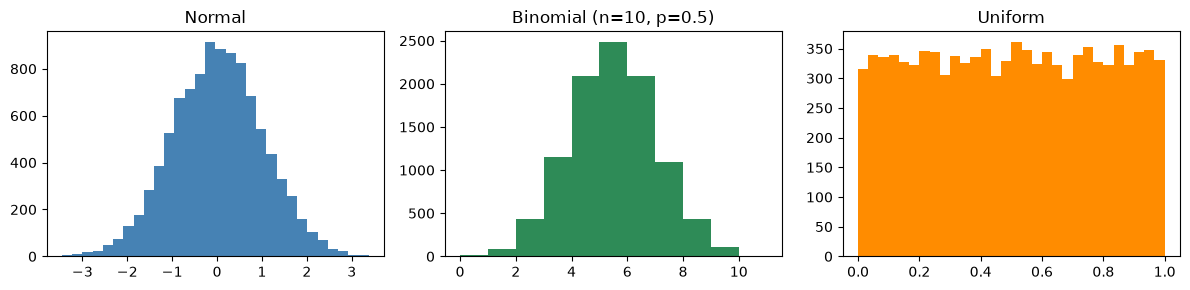

In [3]:
import numpy as np
import matplotlib.pyplot as plt

normal_sample = np.random.normal(loc=0, scale=1, size=10000)
binomial_sample = np.random.binomial(n=10, p=0.5, size=10000)
uniform_sample = np.random.uniform(low=0, high=1, size=10000)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(normal_sample, bins=30, color="steelblue")
axes[0].set_title("Normal")
axes[1].hist(binomial_sample, bins=range(12), color="seagreen")
axes[1].set_title("Binomial (n=10, p=0.5)")
axes[2].hist(uniform_sample, bins=30, color="darkorange")
axes[2].set_title("Uniform")
plt.tight_layout()
plt.show()

## Day 2 Tasks

Now everything under here is for the hands-on lab.

## Step 1 - Simulate 10,000 Coin Flips

Confirm the proportion of heads approaches 0.5 (the Law of Large Numbers).

In [5]:
rng = np.random.default_rng(42)

flips = rng.integers(0, 2, size=10000)   # 0 = tails, 1 = heads
proportion_heads = flips.mean()

print("Proportion of heads:", round(proportion_heads, 4))

Proportion of heads: 0.4939


## Step 2 - Sample from a Normal Distribution

Sample 10,000 points from a normal distribution and plot the histogram to confirm the bell shape.

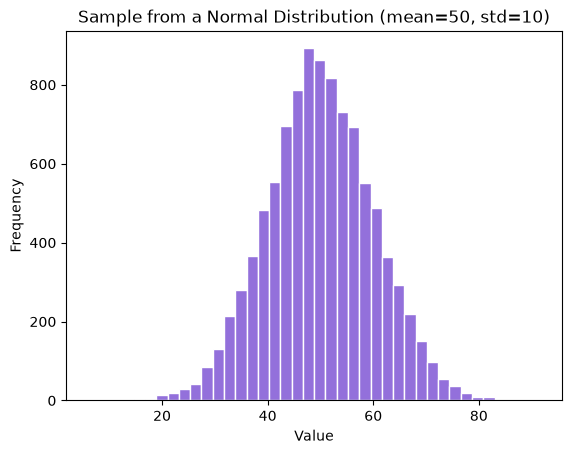

Sample mean: 49.96  Sample std: 10.06


In [6]:
sample = rng.normal(loc=50, scale=10, size=10000)

plt.hist(sample, bins=40, color="mediumpurple", edgecolor="white")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Sample from a Normal Distribution (mean=50, std=10)")
plt.show()

print("Sample mean:", round(sample.mean(), 2), " Sample std:", round(sample.std(), 2))


## Step 3 - Conditional Probability: Worked Scenario + Simulation

Using the IMDb Top 1000 dataset: what is the probability that a movie is highly rated (IMDB_Rating >= 8.5),
given that its genre includes Drama? First compute it directly from the data, then verify it by simulating
random draws from the dataset.


In [7]:
import pandas as pd

imdb = pd.read_csv("../imdb_top_1000.csv")

is_drama = imdb["Genre"].str.contains("Drama")
is_high_rated = imdb["IMDB_Rating"] >= 8.5

p_drama = is_drama.mean()
p_high_rated = is_high_rated.mean()
p_both = (is_drama & is_high_rated).mean()
p_high_given_drama = p_both / p_drama

print("P(Drama):", round(p_drama, 3))
print("P(Rating >= 8.5):", round(p_high_rated, 3))
print("P(Drama and Rating >= 8.5):", round(p_both, 3))
print("P(Rating >= 8.5 | Drama):", round(p_high_given_drama, 3))

P(Drama): 0.724
P(Rating >= 8.5): 0.053
P(Drama and Rating >= 8.5): 0.042
P(Rating >= 8.5 | Drama): 0.058


In [8]:
# Verify by simulation: repeatedly draw a random movie (with replacement)
# and check, among the Drama draws, what fraction were also highly rated.
n_trials = 50000
sample_idx = rng.integers(0, len(imdb), n_trials)
sample = imdb.iloc[sample_idx]

sim_drama = sample["Genre"].str.contains("Drama")
sim_high = sample["IMDB_Rating"] >= 8.5

sim_p_high_given_drama = (sim_drama & sim_high).sum() / sim_drama.sum()
print("Simulated P(Rating >= 8.5 | Drama):", round(sim_p_high_given_drama, 3))

Simulated P(Rating >= 8.5 | Drama): 0.058


**Findings:**

- Coin flips: with 10,000 flips, the proportion of heads landed very close to 0.5, consistent with the Law of
  Large Numbers - the more trials, the closer the empirical probability converges to the true probability.
- Normal sample: the histogram shows the expected symmetric bell shape centered near 50, and the sample mean
  and std closely matched the parameters used to generate it (loc=50, scale=10).
- Conditional probability: the directly-computed P(Rating >= 8.5 | Drama) and the simulated version matched
  closely, confirming the by-hand calculation was correct. Comparing this to the overall P(Rating >= 8.5)
  shows whether being a Drama makes a movie more or less likely to be highly rated in this dataset.